# Machine Learning: Volatility Forecasting

## Introduction
prob, sol, methods, imple

### Imports

In [17]:
import src.paths as paths
import src.volatility as volatility
import src.machine_learning as ml
import src.feature_engineering as fe
from src.data import load_data
import run_updates

from arch import arch_model
import matplotlib.pyplot as plt

# Data

Daily OHLCV data is obtained from yfinance and FRED, and is used to construct the volatility target and endogenous features. VIX is incorporated as an exogneous measure of overall market volatility.

The analysis uses BTC.

Data is loaded through the project's data pipeline which handles retrieval, caching, cleaning, and alignment.

Run this first to fetch the latest stock/market data.

In [ ]:
run_updates.main()

Load the data to be used in the analysis

In [8]:
asset = 'BTC'

ohlcv = load_data(paths.CRYPTO_DATA_PARQUET, '1d')
asset_ohlcv = ohlcv[asset].dropna()

asset_ohlcv.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-08-29,78245.812500,78327.945312,77381.898438,77830.890625,1.405313e+10
2026-08-30,77667.570312,79373.179688,77056.148438,78246.171875,1.931484e+10
2026-08-31,78548.632812,79247.343750,77378.437500,77673.703125,3.060839e+10
2026-09-01,77403.625000,79196.515625,76399.062500,78539.859375,3.060880e+10
2026-09-02,77283.406250,77719.539062,76391.156250,77395.890625,2.826282e+10


# Volatility Target

Parkinson Volatility is used as the target volatility. This measure uses daily high and low prices to incorporate information about intraday variation, providing a better estimate than Realised Absolute Volume which only uses close-to-close prices. Parkinson volatility is a good estimate for 24/7 markets, however it does not account for overnight volatility and price jumps - a weakness when it comes to typical stock market data. To address this, the Yang-Zhang volatility estimator could be implemented for stock market data.

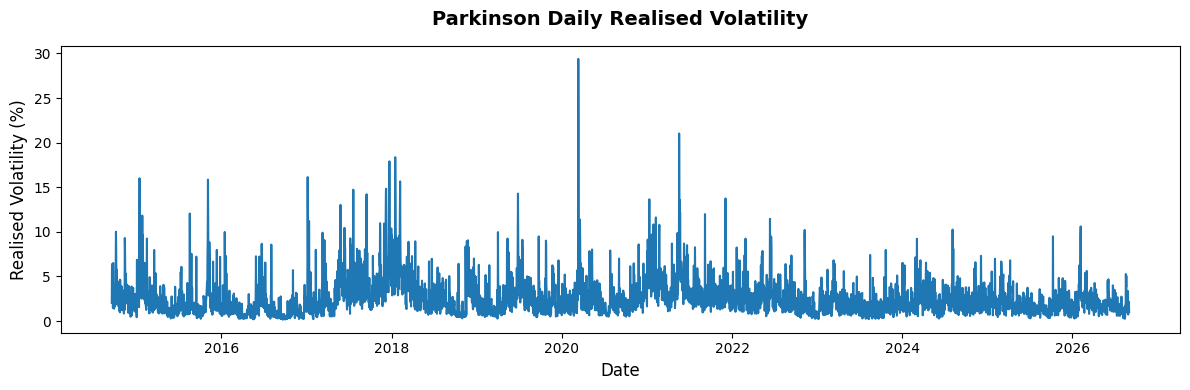

In [15]:
realised_vol = volatility.parkinson_vol(asset_ohlcv)


plt.figure(figsize=(12, 4)) 
plt.plot(realised_vol)
plt.title('Parkinson Daily Realised Volatility', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Realised Volatility (%)', fontsize=12)
plt.tight_layout()
plt.show()


# Feature Engineering

The model uses both endogenous and exogenous volatility information

## (Lagged) Volatility

## (Lagged) Returns

## Moving Averages

## VIX

In [22]:
features = fe.build_ml_features(asset_ohlcv)

features.tail()

Price,Close,High,Low,Open,Volume,Parkinson,VIX_0,Realised_vol_0,Returns_0,VIX_1,...,Price_vs_sma21,Price_vs_sma50,Price_vs_sma200,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,,,,,,,,,,,,,
2026-08-29,78245.812500,78327.945312,77381.898438,77830.890625,1.405313e+10,0.729775,14.43,3.368902,-0.030710,14.51,...,1.076263,1.134705,1.080253,5,3,8,2026,241,29,35
2026-08-30,77667.570312,79373.179688,77056.148438,78246.171875,1.931484e+10,1.779233,14.43,0.729775,0.005325,14.43,...,1.074002,1.134500,1.085092,6,3,8,2026,242,30,35
2026-08-31,78548.632812,79247.343750,77378.437500,77673.703125,3.060839e+10,1.433284,14.43,1.779233,-0.007418,14.43,...,1.059700,1.120574,1.076247,0,3,8,2026,243,31,36
2026-09-01,77403.625000,79196.515625,76399.062500,78539.859375,3.060880e+10,2.159731,14.92,1.433284,0.011280,14.43,...,1.064779,1.127393,1.087499,1,3,9,2026,244,1,36
2026-09-02,77283.406250,77719.539062,76391.156250,77395.890625,2.826282e+10,1.035353,16.34,2.159731,-0.014684,14.92,...,1.044580,1.106146,1.070883,2,3,9,2026,245,2,36


In [23]:
features.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Parkinson', 'VIX_0',
       'Realised_vol_0', 'Returns_0', 'VIX_1', 'Realised_vol_1', 'Returns_1',
       'VIX_2', 'Realised_vol_2', 'Returns_2', 'VIX_5', 'Realised_vol_5',
       'Returns_5', 'VIX_10', 'Realised_vol_10', 'Returns_10', 'VIX_20',
       'Realised_vol_20', 'Returns_20', 'VIX_60', 'Realised_vol_60',
       'Returns_60', 'VIX_120', 'Realised_vol_120', 'Returns_120', 'Vol_7_sma',
       'Vol_7_ema', 'Price_7_sma', 'Price_7_ema', 'Vol_14_sma', 'Vol_14_ema',
       'Price_14_sma', 'Price_14_ema', 'Vol_21_sma', 'Vol_21_ema',
       'Price_21_sma', 'Price_21_ema', 'Vol_50_sma', 'Vol_50_ema',
       'Price_50_sma', 'Price_50_ema', 'Vol_200_sma', 'Vol_200_ema',
       'Price_200_sma', 'Price_200_ema', 'Price_vs_sma7', 'Price_vs_sma21',
       'Price_vs_sma50', 'Price_vs_sma200', 'dayofweek', 'quarter', 'month',
       'year', 'dayofyear', 'dayofmonth', 'weekofyear'],
      dtype='str', name='Price')

# XGBoost Model